# Week 6 — Model Evaluation

## Checking How Good My First Model Is

In the previous task, I trained my first machine learning model and used it to make predictions.

In this task, I am learning how to evaluate the model properly. Just because a model runs and gives predictions, it does not always mean the model is good.

The goal of this notebook is to check the model using accuracy, confusion matrix, and classification report.

# Part 1 — Learning Notes

## Why Accuracy Alone Can Be Misleading

Accuracy tells us how many predictions were correct overall.

For example, if a model gets 90 correct answers out of 100, the accuracy is 90%.

But accuracy alone can sometimes be misleading.

For example, imagine a dataset where 95% of the data belongs to one class. If the model always predicts that majority class, it may get 95% accuracy, but it may still completely fail to identify the smaller class.

So, accuracy is useful, but it does not always show the full story.

## Accuracy Score

Accuracy is the simplest starting metric for checking a model.

It compares the model's predictions with the actual answers and calculates the percentage of correct predictions.

In scikit-learn, we can calculate accuracy using:

`accuracy_score(y_test, predictions)`

## Confusion Matrix

A confusion matrix shows where the model was correct and where it made mistakes.

For classification problems, it compares the actual classes with the predicted classes.

In a confusion matrix:

- Correct predictions usually appear on the main diagonal
- Wrong predictions appear outside the diagonal

For a simple two-class problem, the main ideas are:

- True Positive: the model predicted positive and it was actually positive
- True Negative: the model predicted negative and it was actually negative
- False Positive: the model predicted positive but it was actually negative
- False Negative: the model predicted negative but it was actually positive

For the Iris dataset, there are three flower classes, so the confusion matrix shows how the model predicted each flower type.

## Precision and Recall

Precision means: when the model predicts a class, how often is it correct?

Recall means: out of all the actual items in a class, how many did the model correctly find?

Precision is important when we want the model to be careful before saying something is positive.

Recall is important when we do not want the model to miss important positive cases.

For example, in medical testing, recall can be very important because missing a real disease case can be dangerous.

## Why We Evaluate on the Test Set

We evaluate the model on the test set because the test set contains data the model did not see during training.

If we evaluate only on the training data, the model may look very good because it already learned from that data.

Testing on unseen data gives a more honest idea of how well the model may perform on new data.

In [1]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
# Load the Iris dataset

iris = load_iris()

In [3]:
# Convert the Iris dataset into a pandas DataFrame

df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target column
df["target"] = iris.target

# Add flower species names for easier understanding
df["target_name"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

# Display the first few rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


# Dataset Used

The dataset used in this notebook is the Iris dataset from scikit-learn.

It contains flower measurements for three Iris flower species:

- Setosa
- Versicolor
- Virginica

The goal is to use the flower measurements to predict the flower species.

This is a classification task because the model is predicting a category.

In [4]:
# Show the first five rows

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [5]:
# Show summary statistics

df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [6]:
# Count how many records are available for each flower type

df["target_name"].value_counts()

,count
target_name,
setosa,50
versicolor,50
virginica,50


# Identifying X and y

In this dataset, X contains the input features.

The features are:

- sepal length
- sepal width
- petal length
- petal width

The y value is the label or target.

For this dataset, y is the flower species.

In [7]:
# Create X and y

X = df[iris.feature_names]
y = df["target"]

# Train/Test Split

The data is split into training data and test data.

The training data is used to teach the model.

The test data is used to evaluate the model on data it has not seen before.

This helps us check the model more honestly.

In [8]:
# Split the dataset into training and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
# Check the size of training and test data

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


# Training the Original Model

I am using K-Nearest Neighbors as the model.

For the first model, I will use `n_neighbors=3`.

This means the model checks the 3 closest examples before making a prediction.

In [10]:
# Create the original KNN model

model = KNeighborsClassifier(n_neighbors=3)

# Train the model
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [11]:
# Make predictions on the test data

predictions = model.predict(X_test)

# Accuracy Score

Accuracy shows how many predictions the model got correct overall.

It is a useful starting point, but it does not always show the full story. That is why I will also use a confusion matrix and classification report.

In [12]:
# Calculate accuracy on the test set

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


In [13]:
# Compare predicted answers with actual answers

comparison = pd.DataFrame({
    "Predicted Number": predictions,
    "Predicted Flower": iris.target_names[predictions],
    "Actual Number": y_test.values,
    "Actual Flower": iris.target_names[y_test.values]
})

comparison["Match"] = comparison["Predicted Number"] == comparison["Actual Number"]

comparison["Match"] = comparison["Match"].map({
    True: "Yes",
    False: "No"
})

comparison.head(10)

,Predicted Number,Predicted Flower,Actual Number,Actual Flower,Match
0,0,setosa,0,setosa,Yes
1,2,virginica,2,virginica,Yes
2,1,versicolor,1,versicolor,Yes
3,1,versicolor,1,versicolor,Yes
4,0,setosa,0,setosa,Yes
5,1,versicolor,1,versicolor,Yes
6,0,setosa,0,setosa,Yes
7,0,setosa,0,setosa,Yes
8,2,virginica,2,virginica,Yes
9,1,versicolor,1,versicolor,Yes


# Confusion Matrix

The confusion matrix helps me see where the model was correct and where it made mistakes.

The correct predictions appear on the diagonal.

If there are values outside the diagonal, that means the model confused one class with another.

In [14]:
# Generate the confusion matrix

cm = confusion_matrix(y_test, predictions)

cm

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  0, 10]])

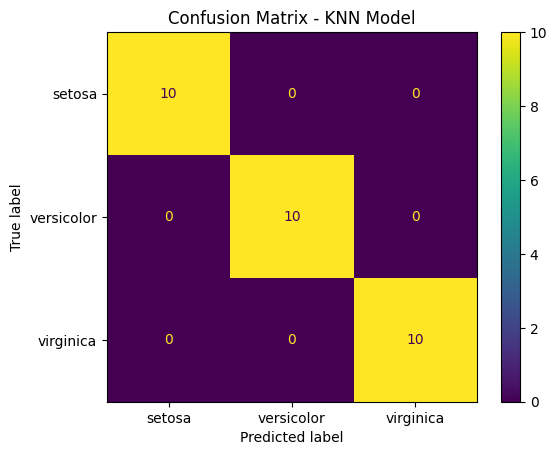

In [15]:
# Visualize the confusion matrix using matplotlib

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

display.plot()
plt.title("Confusion Matrix - KNN Model")
plt.show()

# Confusion Matrix Observation

From the confusion matrix, I can see how many flowers were correctly classified for each species.

The diagonal values show the correct predictions.

In my result, the model performed very well because most or all values are on the diagonal.

This means the model did not confuse the flower species much in the test set.

# Classification Report

The classification report shows precision, recall, F1-score, and support for each class.

Precision tells me how correct the model was when it predicted a class.

Recall tells me how many actual items from a class the model was able to find.

Support tells me how many test samples were available for each class.

In [16]:
# Print the classification report

print(classification_report(
    y_test,
    predictions,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# My Understanding of Precision and Recall

Precision tells me how reliable the model is when it predicts a flower species.

For example, if the model predicts Setosa, precision tells me how often that prediction was actually correct.

Recall tells me how well the model found all flowers of a particular species.

For example, if there were 10 actual Setosa flowers, recall tells me how many of those Setosa flowers the model correctly identified.

In this task, precision and recall help me understand the model better than accuracy alone.

# Retraining with a Different Setting

Now I will retrain the model with a different setting.

The first model used `n_neighbors=3`.

The second model will use `n_neighbors=1`.

This means the second model will only look at the single closest example before making a prediction.

I want to check whether this changes the accuracy.

In [17]:
# Create a second KNN model with a different setting

model_k1 = KNeighborsClassifier(n_neighbors=1)

# Train the second model
model_k1.fit(X_train, y_train)

# Make predictions with the second model
predictions_k1 = model_k1.predict(X_test)

In [18]:
# Calculate accuracy for the second model

accuracy_k1 = accuracy_score(y_test, predictions_k1)

print("Accuracy with n_neighbors=3:", accuracy)
print("Accuracy with n_neighbors=1:", accuracy_k1)

Accuracy with n_neighbors=3: 1.0
Accuracy with n_neighbors=1: 0.9666666666666667


In [19]:
# Compare predictions from both model settings

model_comparison = pd.DataFrame({
    "Actual Flower": iris.target_names[y_test.values],
    "Prediction with 3 Neighbors": iris.target_names[predictions],
    "Prediction with 1 Neighbor": iris.target_names[predictions_k1]
})

model_comparison["Prediction Changed"] = predictions != predictions_k1

model_comparison

,Actual Flower,Prediction with 3 Neighbors,Prediction with 1 Neighbor,Prediction Changed
0,setosa,setosa,setosa,False
1,virginica,virginica,virginica,False
2,versicolor,versicolor,versicolor,False
3,versicolor,versicolor,versicolor,False
4,setosa,setosa,setosa,False
5,versicolor,versicolor,versicolor,False
6,setosa,setosa,setosa,False
7,setosa,setosa,setosa,False
8,virginica,virginica,virginica,False
9,versicolor,versicolor,versicolor,False


In [20]:
# Count how many predictions changed

changed_count = (predictions != predictions_k1).sum()

print("Number of predictions changed:", changed_count)

Number of predictions changed: 1


# Comparison Observation

In my result, changing `n_neighbors` did not improve the model accuracy. Both settings performed similarly on this test set.

After changing `n_neighbors` from 3 to 1, I compared the new accuracy with the old accuracy.

In my result, the model with `n_neighbors=3` performed slightly better than the model with `n_neighbors=1`.

My understanding is that using only 1 neighbor can make the model more sensitive to one nearby example.

Using 3 neighbors can sometimes be more stable because the model checks more nearby examples before deciding.

# How Good Is My Model, Honestly — And Would I Trust It?

Honestly, my model performed very well on this test set.

The accuracy was high, and the confusion matrix showed that the model correctly predicted most or all flower species.

The classification report also showed strong precision and recall values.

I would trust this model for this small Iris dataset because the data is clean, balanced, and the classes have useful measurement patterns.

However, I would not blindly trust it for every real-world problem. This is a small beginner dataset, so real-world data may be messier and more difficult.

This task helped me understand that a model should not only run. It should also be evaluated properly before saying it is good.